#Importing All The Packages and Classes
->torchvision for dealing with images
->datasets given by pytorch
->transforms used for data augmentations
->ToTensor is used to convert datasets(each image) into tensors
->matplotlib.pyplot as plt for plotting

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [2]:
#downloading Datasets of FashionMNIST
train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.62MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 53.2MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.6MB/s]


#Get Class names for labels and convert it to numbers or index

In [3]:
class_names=train_data.classes
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

# Trying to show the image

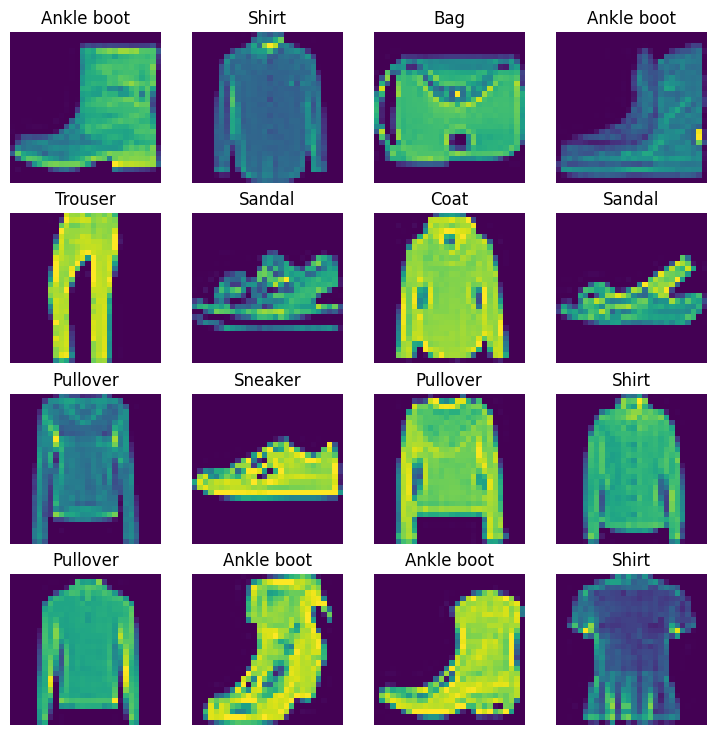

In [4]:
torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  img,label=train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze())
  plt.title(class_names[label])
  plt.axis(False)

In [5]:
from torch.utils.data import DataLoader
Batch_size=32
train_dataloader=DataLoader(dataset=train_data,batch_size=Batch_size,shuffle=True)
test_dataloader=DataLoader(dataset=test_data,batch_size=Batch_size,shuffle=True)
image_features,single_batch_image_indexes=next(iter(train_dataloader))
image_features,single_batch_image_indexes

(tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0157, 0.0000, 0.0039],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

In [6]:
#devic agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
class FashionModel_0(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(nn.Flatten(),nn.Linear(
        in_features=input_shape,
        out_features=hidden_units),nn.Linear(in_features=hidden_units,out_features=output_shape)
    )
  def forward(self,x):
    return self.layer_stack(x)

Check if Everything is ok

In [8]:
model_0=FashionModel_0(784,10,len(class_names)).to(device)
dummy_data=torch.rand([1,1,28,28])
model_0(dummy_data.to(device))

tensor([[-0.4711, -0.4828,  0.2783,  0.0113, -0.1184,  0.2814,  0.0589,  0.1635,
          0.0952,  0.1976]], device='cuda:0', grad_fn=<AddmmBackward0>)

#using helper_function and to write loss and accuracy

In [9]:
# @title
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
  print("already there")
else:
  print("downloading")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open('helper_functions.py','wb') as f:
    f.write(request.content)

downloading


In [10]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)
#use timer function to track the time taken
from timeit import default_timer as timer
def print_train_time(start:float,end:float,device:torch.device='cpu'):
  total_time=(end-start)
  return total_time

#training function
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device=device):
  model.train()
  train_loss,train_acc=0,0
  for batch,(X,y) in enumerate(dataloader):
    X=X.to(device)
    y=y.to(device)
    y_pred_logits=model(X)
    loss=loss_fn(y_pred_logits,y)
    train_loss+=loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred=torch.argmax(y_pred_logits,dim=1)
    train_acc+=((y_pred==y).sum().item())

  train_loss=train_loss/len(dataloader)
  train_acc=train_acc/len(dataloader.dataset)
  return train_loss,train_acc

#testing function
def test_step(model:torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              device:torch.device="cpu",
              ):

  model.eval()
  test_loss,test_acc=0,0
  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X=X.to(device)
      y=y.to(device)
      y_pred_logits=model(X)
      loss=loss_fn(y_pred_logits,y)
      test_loss+=loss.item()

      y_pred=torch.argmax(y_pred_logits,dim=1)
      test_acc+=((y_pred==y).sum().item())

  test_loss=test_loss/len(dataloader)
  test_acc=test_acc/len(dataloader.dataset)
  return test_loss,test_acc

In [11]:
from tqdm.auto import tqdm
torch.manual_seed(42)
train_time_strt=timer()
epochs=10
for epoch in tqdm(range(epochs)):
  train_loss,train_acc=train_step(model_0.to(device),train_dataloader,loss_fn,optimizer,device)
  test_loss,test_acc=test_step(model_0.to(device),test_dataloader,loss_fn,device)

  print(f"train loss:{train_loss} | train acc:{train_acc} | test loss: {test_loss} |test acc: {test_acc}")

  0%|          | 0/10 [00:00<?, ?it/s]

train loss:0.8901721421400706 | train acc:0.7190666666666666 | test loss: 0.6289708834296217 |test acc: 0.7817
train loss:0.5623750794649124 | train acc:0.8074666666666667 | test loss: 0.5495937449006608 |test acc: 0.8097
train loss:0.5061246378739674 | train acc:0.82615 | test loss: 0.5134725602575765 |test acc: 0.8235
train loss:0.47860560261408486 | train acc:0.8339333333333333 | test loss: 0.4950233671231011 |test acc: 0.8277
train loss:0.46157569584051766 | train acc:0.8403666666666667 | test loss: 0.48562642413015944 |test acc: 0.8288
train loss:0.4490074259161949 | train acc:0.8443166666666667 | test loss: 0.47469203416912703 |test acc: 0.8309
train loss:0.4407289424578349 | train acc:0.8476666666666667 | test loss: 0.46836674794221456 |test acc: 0.8348
train loss:0.4341999828537305 | train acc:0.8488833333333333 | test loss: 0.4810926825188981 |test acc: 0.8323
train loss:0.4287011829296748 | train acc:0.8522666666666666 | test loss: 0.45793969900653764 |test acc: 0.8373
train 

In [15]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [12]:
#score card of the model
def eval_model(model:torch.nn.Module,dataloader:torch.utils.data.DataLoader,loss_fn:torch.nn.Module,device):
  loss,acc=0,0
  model.eval()
  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X=X.to(device)
      y=y.to(device)
      y_logits=model(X)
      y_pred=torch.argmax(y_logits,dim=1)
      loss+=loss_fn(y_logits,y)
      acc+=accuracy_fn(y,y_pred)
    loss/=len(dataloader)
    acc/=len(dataloader)
  return {"model name":model.__class__.__name__,"model_loss":loss.item(),"accuracy":acc}

In [16]:
model_0_results=eval_model(model=model_0.to(device),dataloader=test_dataloader,loss_fn=loss_fn,device=device)
model_0_results

{'model name': 'FashionModel_0',
 'model_loss': 0.45964425802230835,
 'accuracy': 83.36661341853035}

In [17]:
#Using convolution block

class fashionConvo(nn.Module):
  def  __init__(self,input_shape,hidden_units,output_units):

    super().__init__()
    self.conv_block_1=nn.Sequential(nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=2,stride=1,padding=3),
                                    nn.ReLU(),
                                    nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=2,stride=1,padding=3),
                                    nn.ReLU(),
                                    nn.MaxPool2d(kernel_size=2))
    self.conv_block_2=nn.Sequential(nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=2,stride=1,padding=0),
                                    nn.ReLU(),
                                    nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=2,stride=1,padding=0),
                                    nn.ReLU(),
                                    nn.MaxPool2d(kernel_size=2))
    self.classifier=nn.Sequential(nn.Flatten(),nn.Linear(in_features=hidden_units*8*8,
                                    out_features=output_units))
  def forward(self,x):
    x=self.conv_block_1(x)
    x=self.conv_block_2(x)
    x=self.classifier(x)
    return x

In [18]:
model_1=fashionConvo(1,128,len(class_names)).to(device)
optimizer=torch.optim.Adam(params=model_1.parameters(),lr=0.001)

In [19]:
image=torch.randn(size=(32,3,64,64))
test_image=image[0]
test_image.shape

torch.Size([3, 64, 64])

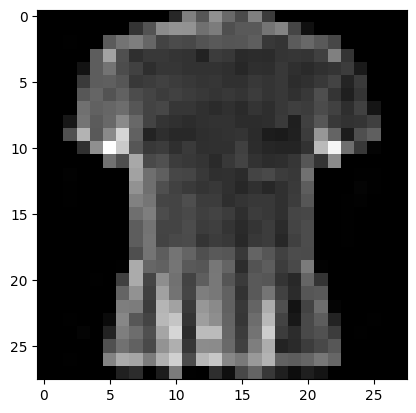

In [20]:
plt.imshow(img.squeeze(),cmap="gray")

In [21]:
model_1(img.unsqueeze(dim=0).to(device))

tensor([[-0.0136, -0.0023, -0.0433, -0.0391,  0.0015,  0.0061, -0.0027, -0.0213,
         -0.0099, -0.0029]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [22]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs=10
for epoch in tqdm(range(epochs)):
  train_loss,train_acc=train_step(model_1.to(device),dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device)
  test_loss,test_acc=test_step(model_1.to(device),dataloader=test_dataloader,loss_fn=loss_fn,
             device=device)
  print(f"train loss:{train_loss} | train acc:{train_acc} | test loss: {test_loss} | test acc:{test_acc}")

  0%|          | 0/10 [00:00<?, ?it/s]

train loss:0.3983989433467388 | train acc:0.8566 | test loss: 0.29919323421562444 | test acc:0.8938
train loss:0.25847451788981757 | train acc:0.9076166666666666 | test loss: 0.2781701161981391 | test acc:0.8984
train loss:0.21593222069938978 | train acc:0.9212 | test loss: 0.24525896369958647 | test acc:0.915
train loss:0.1903476190586885 | train acc:0.9304166666666667 | test loss: 0.24548771167501285 | test acc:0.914
train loss:0.17066999866018692 | train acc:0.9377666666666666 | test loss: 0.2391212212141996 | test acc:0.9163
train loss:0.1516060365428527 | train acc:0.9453166666666667 | test loss: 0.23877471253371085 | test acc:0.9195
train loss:0.1368545008952419 | train acc:0.9503333333333334 | test loss: 0.23769036265084156 | test acc:0.9209
train loss:0.120366352477173 | train acc:0.9560666666666666 | test loss: 0.2636403541285961 | test acc:0.9157
train loss:0.10807416030963261 | train acc:0.96095 | test loss: 0.2708784484426482 | test acc:0.9179
train loss:0.09599542793609822

In [23]:
#make and evaluate random predictions
def make_prediction(model,data,device=device):
  pred_probs=[]
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample=torch.unsqueeze(sample,dim=0).to(device)
      pred_logits=model(sample)
      pred_prob=torch.softmax(pred_logits.squeeze(),dim=0)
      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

In [24]:
import random
test_samples=[]
test_labels=[]
for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)
test_samples[0].shape

torch.Size([1, 28, 28])

In [25]:
pred_probs=make_prediction(model=model_1,data=test_samples)
pred_probs

tensor([[2.4383e-07, 9.7549e-13, 9.9943e-01, 2.2903e-08, 5.5459e-04, 3.9279e-13,
         1.2507e-05, 1.4506e-18, 4.3519e-07, 1.0337e-08],
        [4.4155e-09, 1.0000e+00, 1.8722e-09, 4.5330e-09, 1.0144e-08, 1.9021e-10,
         3.7030e-10, 5.4850e-15, 1.2163e-09, 1.0193e-12],
        [1.1790e-09, 3.0953e-15, 8.1456e-11, 3.0912e-15, 2.8316e-14, 1.0000e+00,
         1.3689e-13, 1.5867e-08, 1.2410e-08, 3.5858e-12],
        [4.1440e-13, 9.8059e-23, 5.1826e-15, 1.8582e-17, 8.8344e-16, 1.0000e+00,
         8.4964e-17, 2.4486e-16, 3.4788e-14, 1.0236e-14],
        [4.1416e-05, 4.0006e-07, 3.9155e-08, 9.9996e-01, 8.9014e-11, 7.6348e-09,
         2.2712e-06, 3.2866e-14, 2.4554e-08, 2.3332e-08],
        [5.2350e-01, 5.7158e-08, 2.7692e-05, 3.1009e-04, 8.4184e-10, 9.8273e-10,
         4.7616e-01, 2.8237e-13, 6.3440e-08, 3.3119e-08],
        [2.0538e-05, 7.8129e-08, 1.0392e-04, 4.2961e-06, 7.0182e-06, 6.2504e-03,
         4.6116e-07, 9.7260e-01, 2.6199e-05, 2.0985e-02],
        [1.3156e-04, 8.2103

In [26]:
model_1_results=eval_model(model=model_1.to(device),dataloader=test_dataloader,loss_fn=loss_fn,device=device)

In [27]:
model_1_results,model_0_results

({'model name': 'fashionConvo',
  'model_loss': 0.2685805857181549,
  'accuracy': 92.1026357827476},
 {'model name': 'FashionModel_0',
  'model_loss': 0.45964425802230835,
  'accuracy': 83.36661341853035})

In [28]:
pred_classes=pred_probs.argmax(dim=1)
pred_classes

tensor([2, 1, 5, 5, 3, 0, 7, 2, 4])

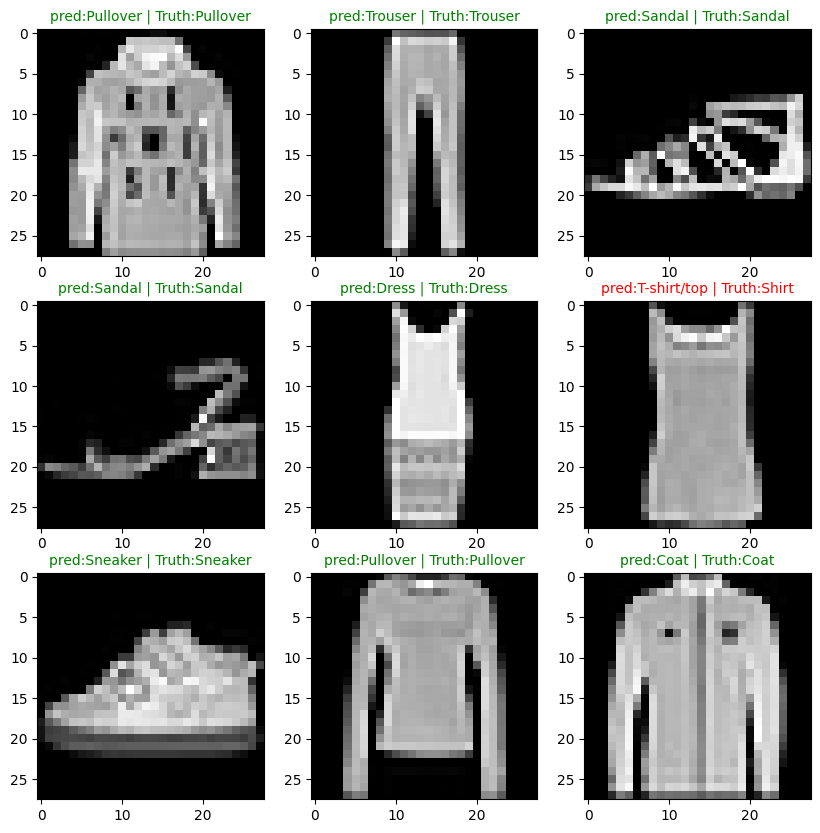

In [29]:
#plot predictions

plt.figure(figsize=(10,10))
nrows=3
ncols=3
for i,sample in enumerate(test_samples):
  plt.subplot(nrows,ncols,i+1)
  plt.imshow(sample.squeeze(),cmap="gray")
  pred_label=class_names[pred_classes[i]]
  truth_label=class_names[test_labels[i]]
  title_text=f"pred:{pred_label} | Truth:{truth_label}"
  if pred_label==truth_label:
    plt.title(title_text,fontsize=10,color="g")
  else:
    plt.title(title_text,fontsize=10,color='r')
